In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from collections import Counter
from scipy.stats import chi2_contingency

In [2]:
regions = ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]
df = (
    pd.read_csv("data/ab_ag_annotated_test.tsv", sep="\t")
    .dropna(subset = regions)
    .drop_duplicates(subset = regions)
    .reset_index(drop = True)
)
antigen_counts = df["antigen_name"].value_counts()
antigen_names_with_min_10 = antigen_counts[antigen_counts >= 10].index
df = df[df["antigen_name"].isin(antigen_names_with_min_10)].reset_index(drop=True)

antigen_labels = df["antigen_name"].tolist()

In [3]:
feature_spaces = {}
for region in regions:
    fs_rows = []
    for df_row in df.itertuples():
        # Metadaten der PDB-Einträge
        pdb = df_row.pdb
        antigen_name = df_row.antigen_name
        antigen_species = df_row.antigen_species

        # Embedding-Koordinaten der PDB-Einträge
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)
    
    # Umwandeln des Feature-Space von einer List in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"embedding_dimension {e}" for e in range(embedding_as_vec.shape[0])])
    feature_spaces[region] = feature_space

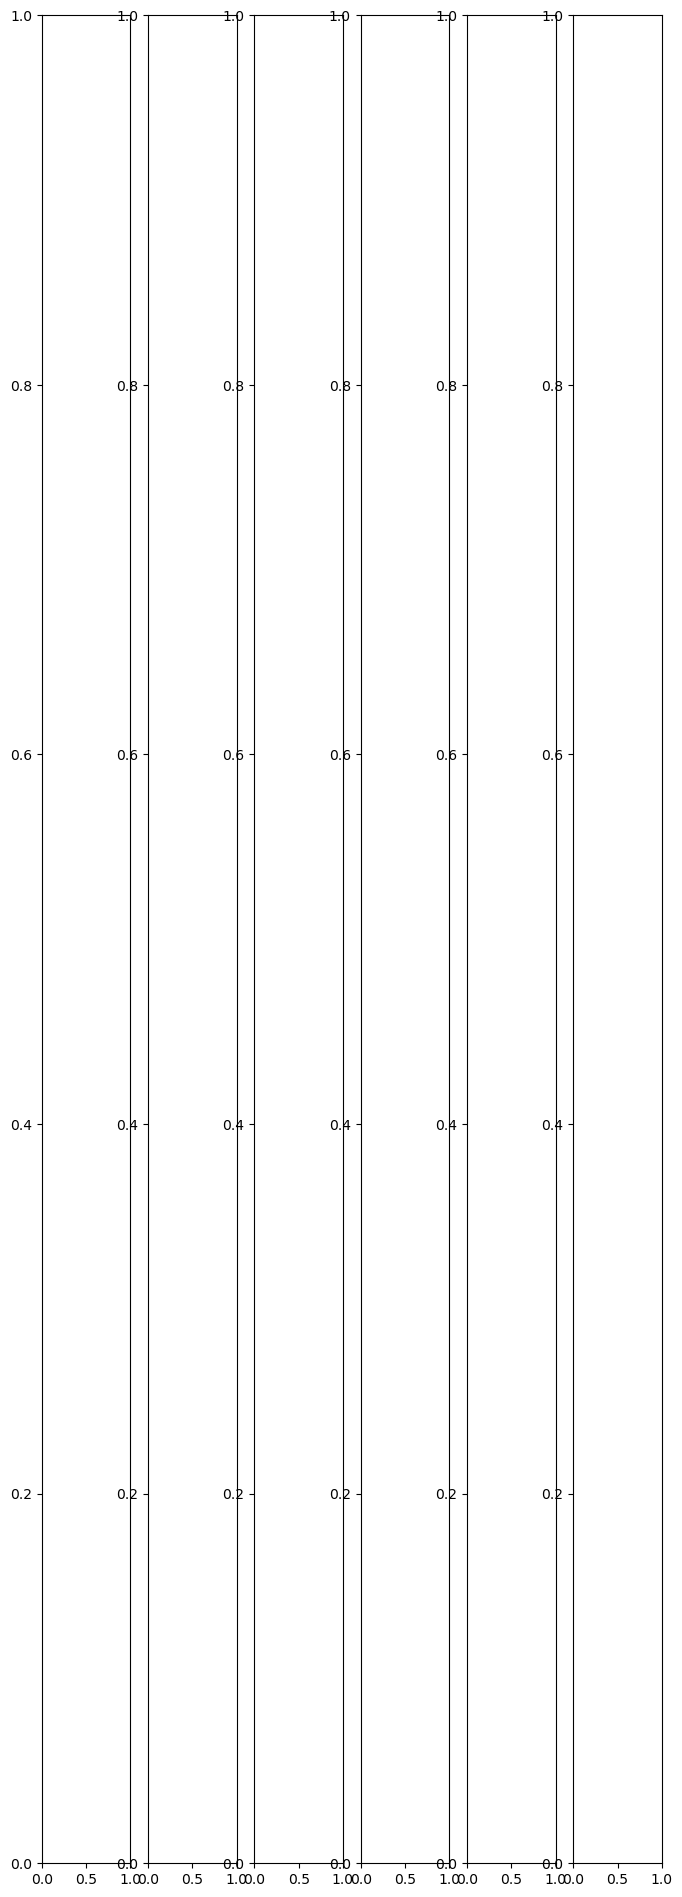

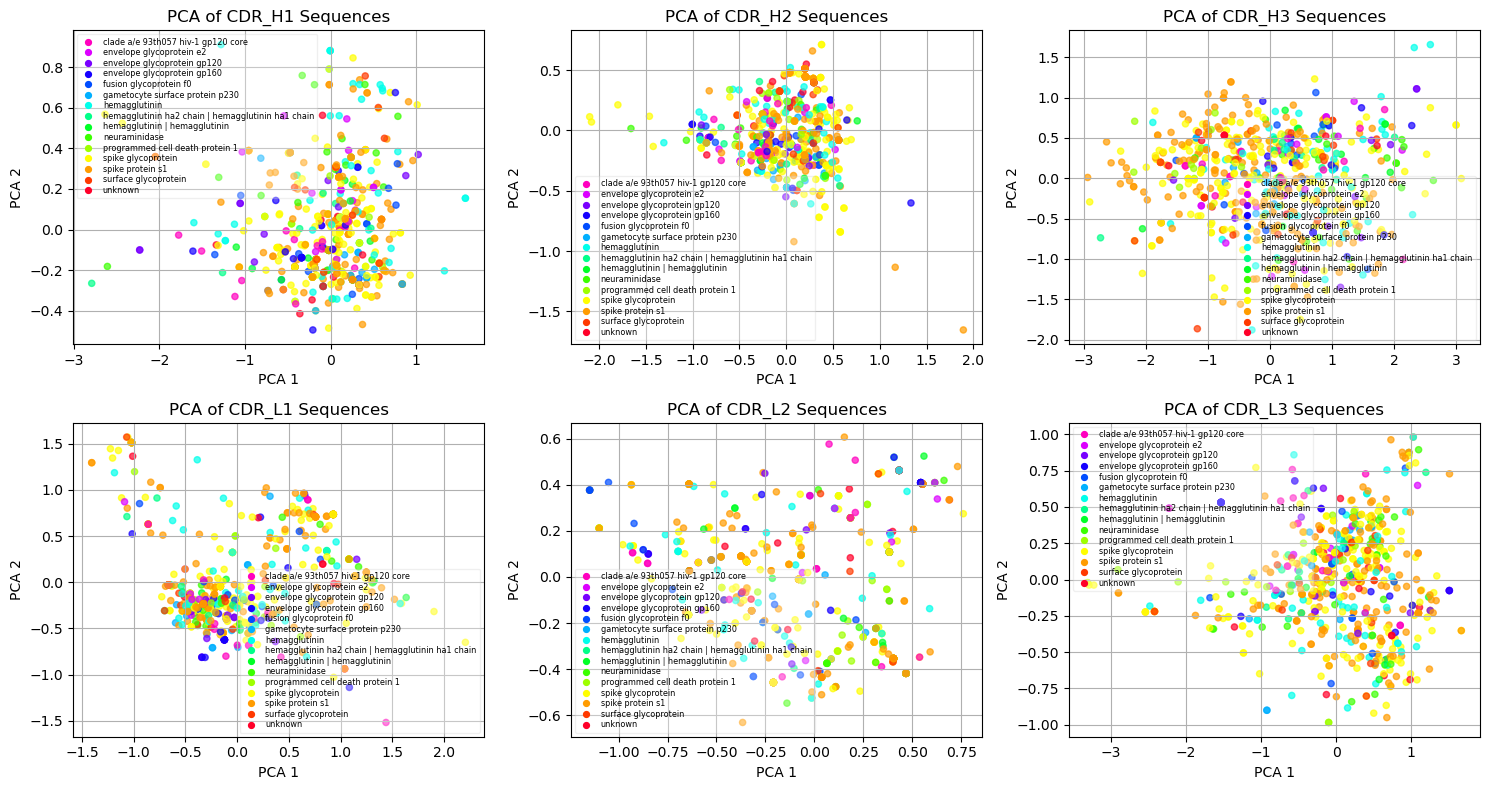

In [4]:
from data_cleanup.functions import show_PCA
show_PCA(feature_spaces, 3)

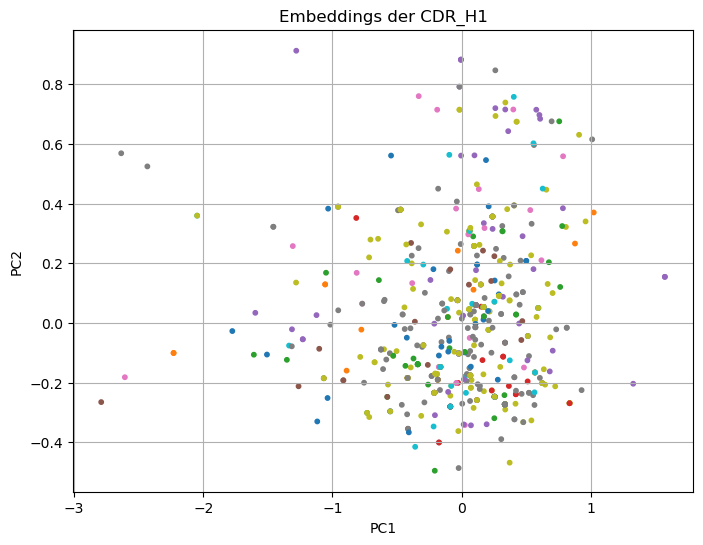

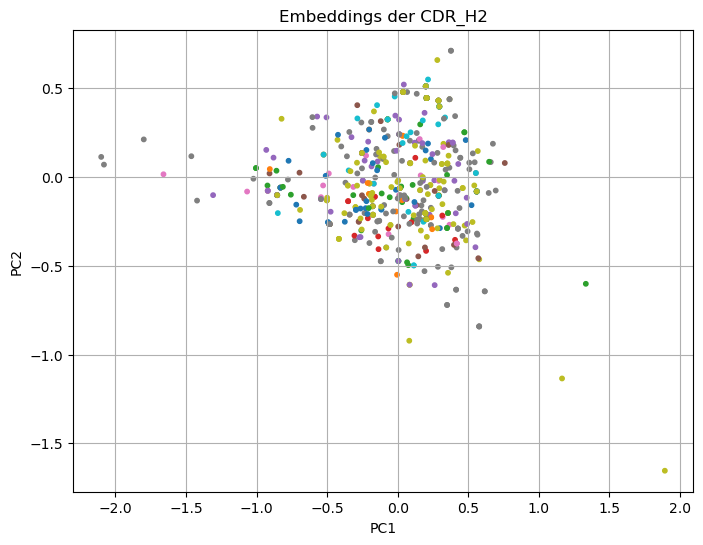

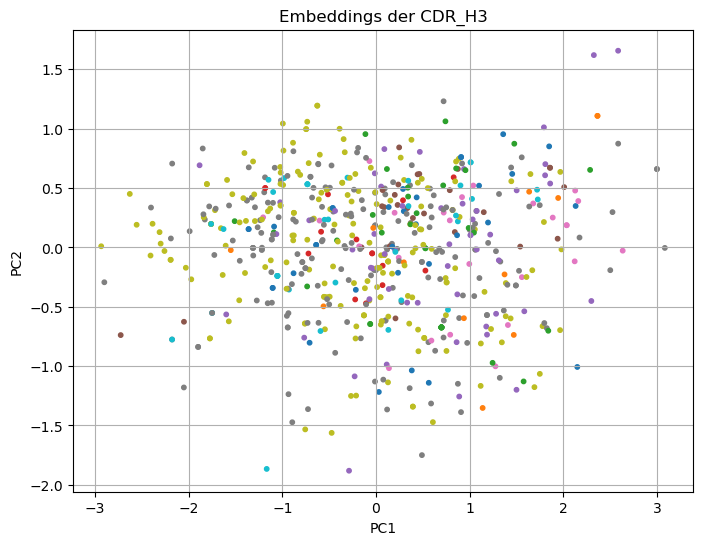

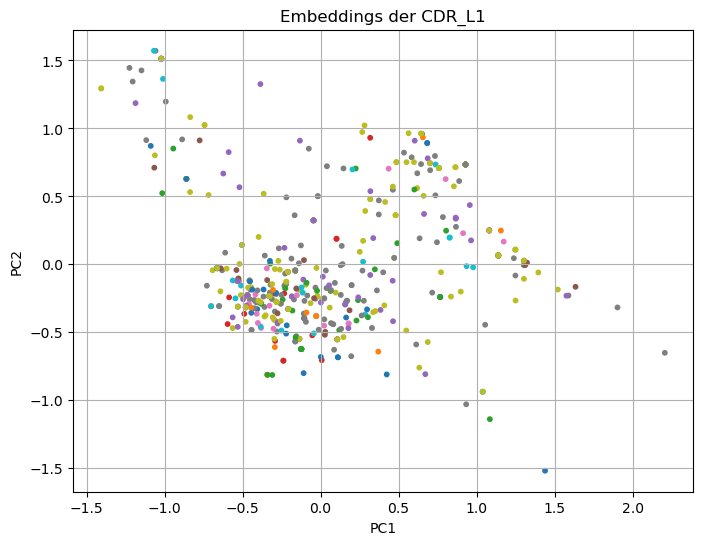

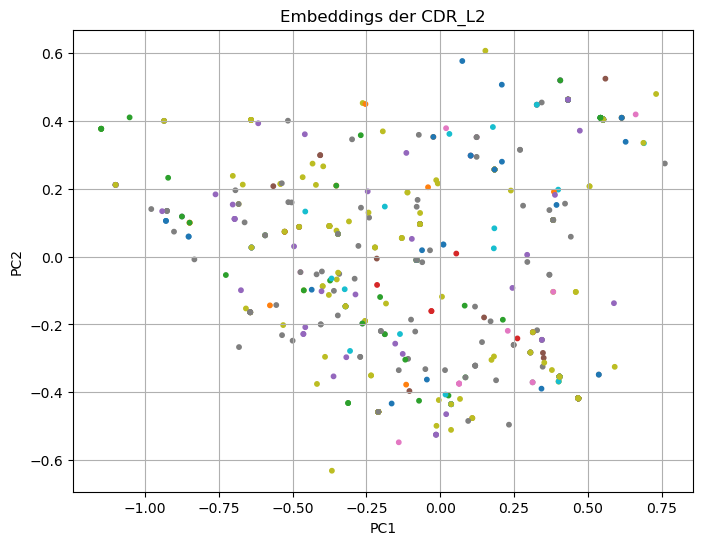

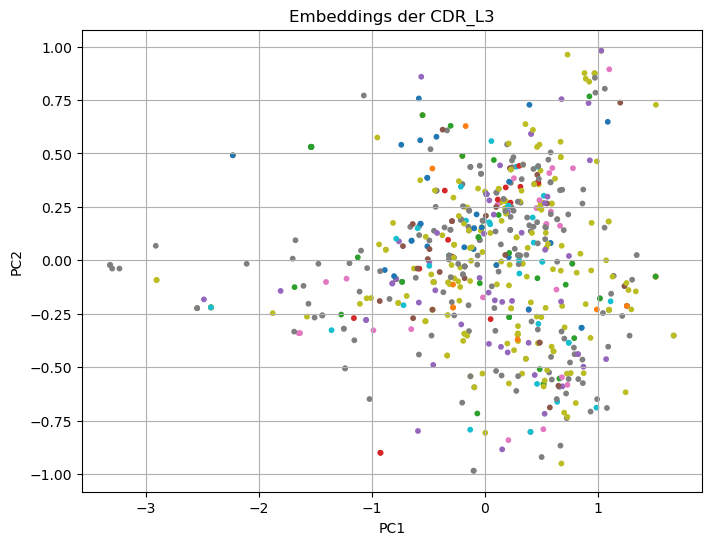

In [5]:
# Visualisierung der Embeddings in 2D mit PCA    
for region in regions:
    feature_space = feature_spaces[region]    
    X = feature_space.drop(columns=["pdb"] + ["antigen_name"] + ["antigen_species"]).values
    X_2d = PCA(n_components=2).fit_transform(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=pd.Categorical(feature_space["antigen_name"]).codes, cmap='tab10', s=10)
    plt.title(f"Embeddings der {region}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    #labels = KMeans(n_clusters=10, random_state=42).fit_predict(X) (für KMeans-Clustering)


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

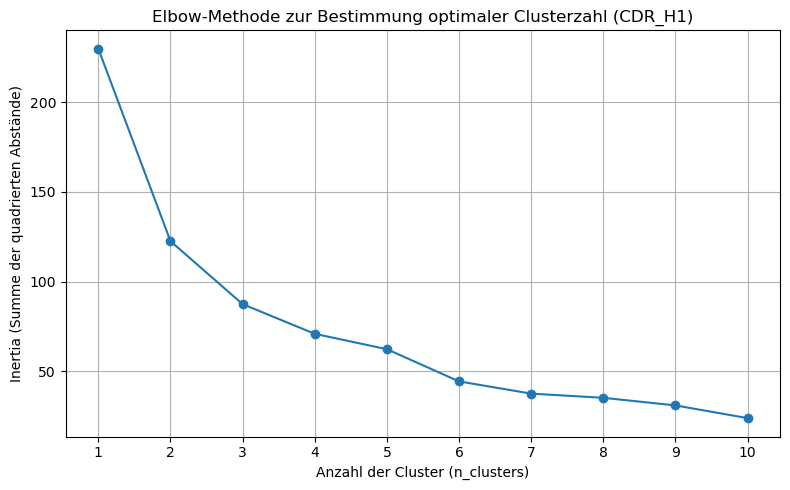

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

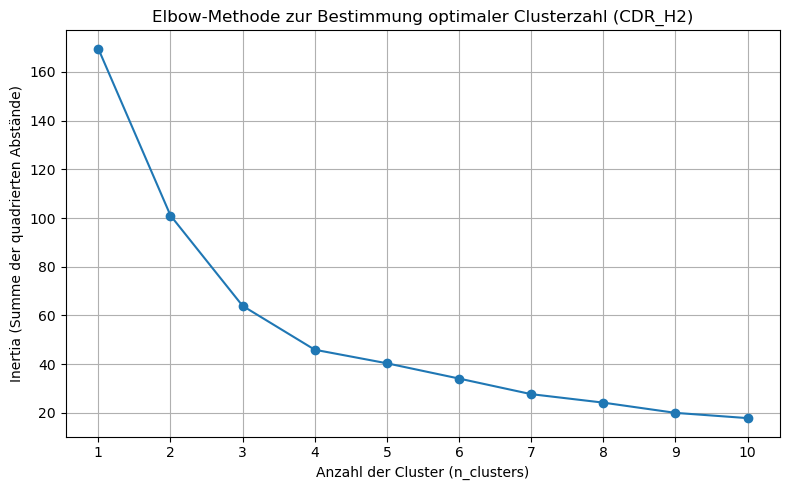

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

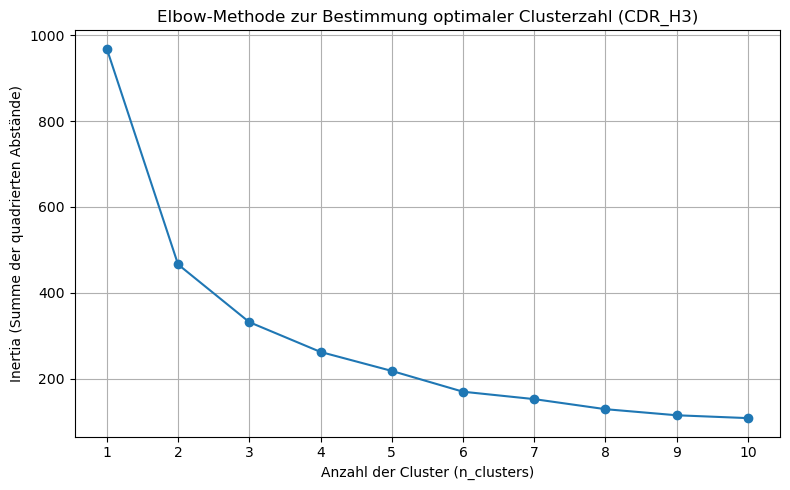

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

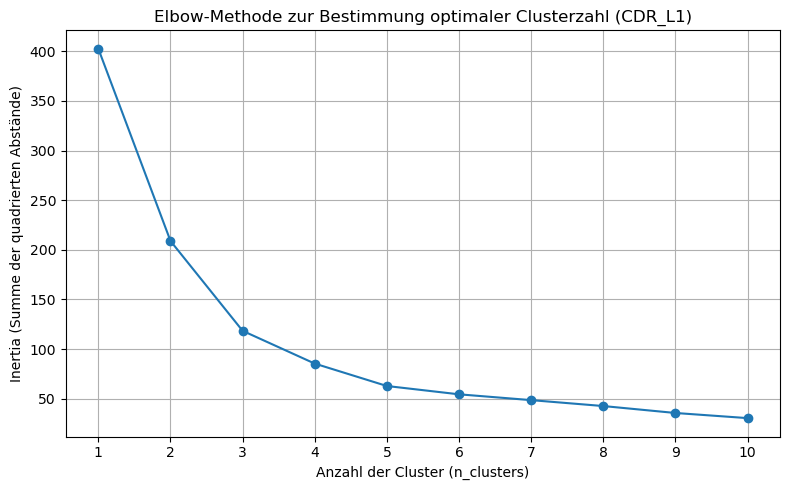

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

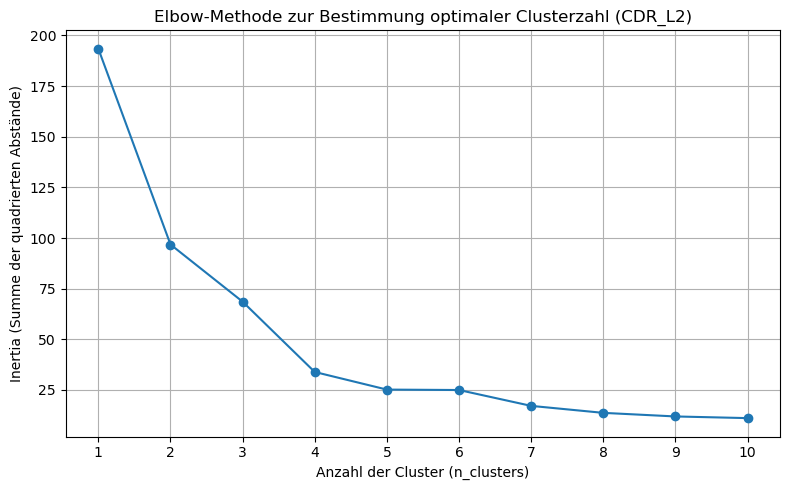

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

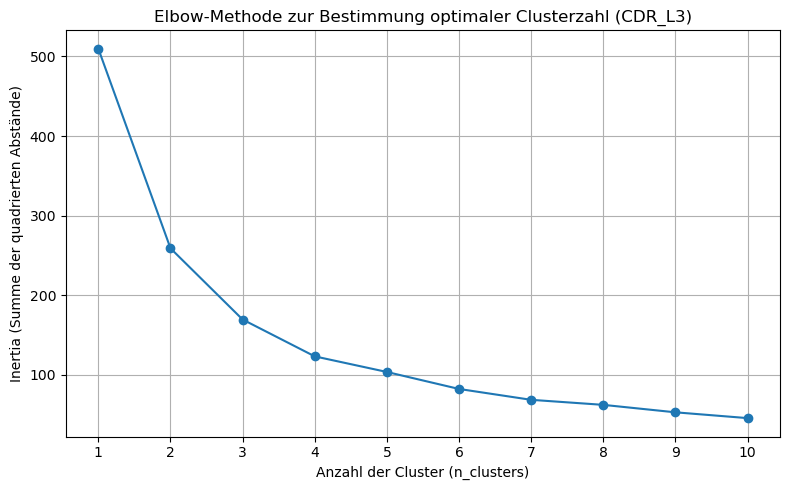

In [6]:
# Elbow-Methode zur Bestimmung der optimalen Clusterzahl

for region in regions:
    feature_space_elbow = feature_spaces[region]

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns = ["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

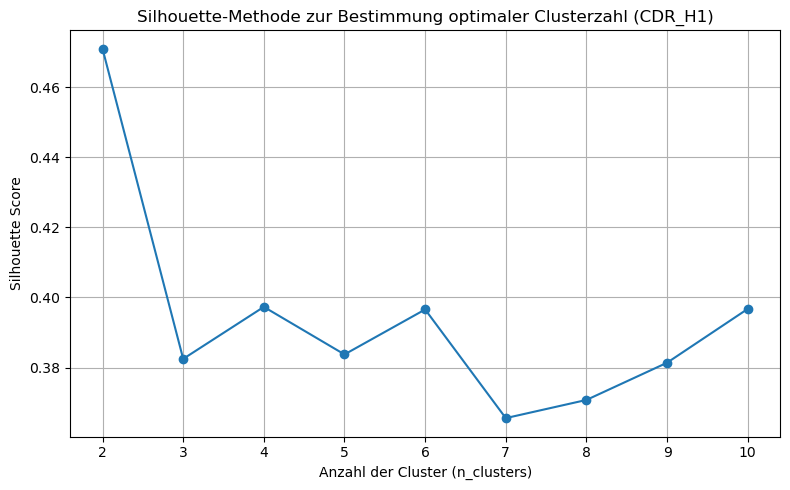

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

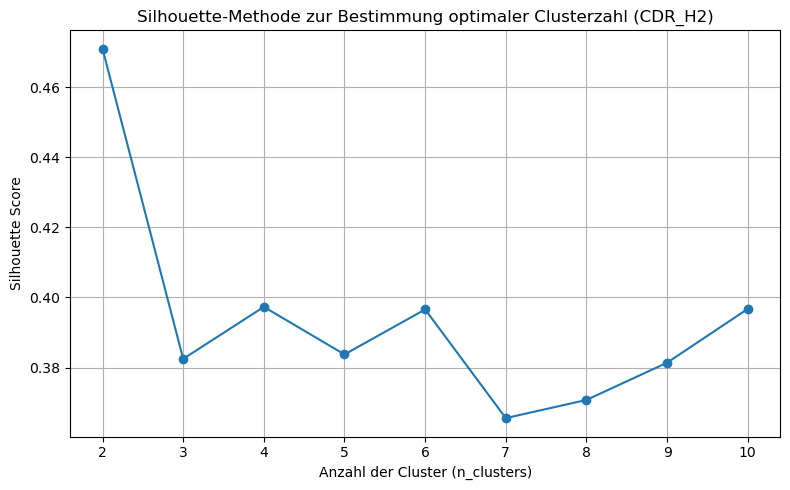

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

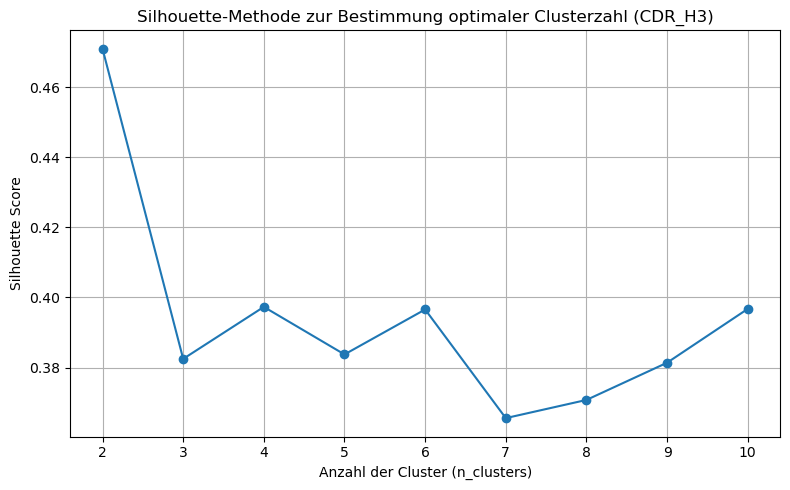

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

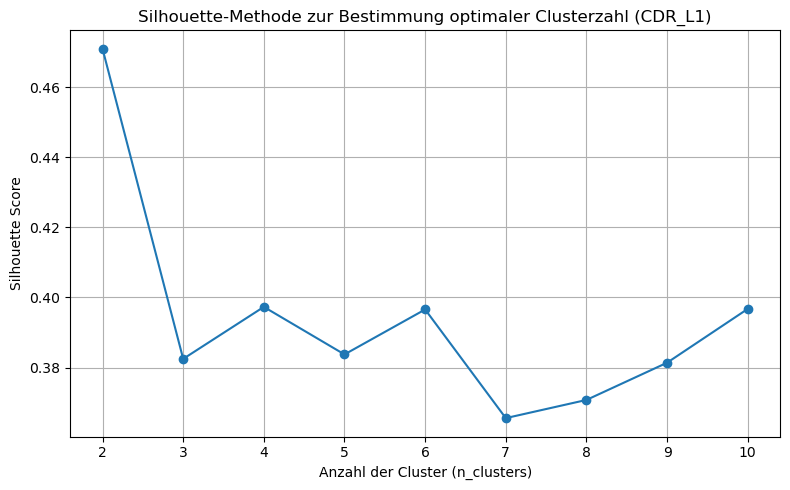

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

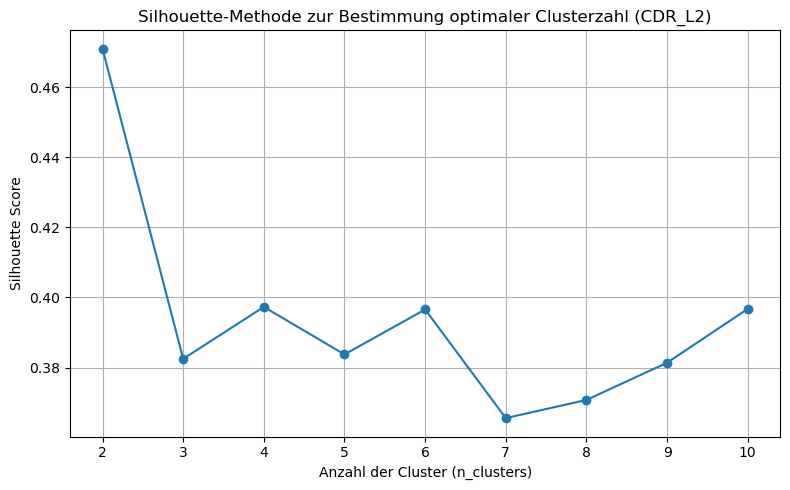

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

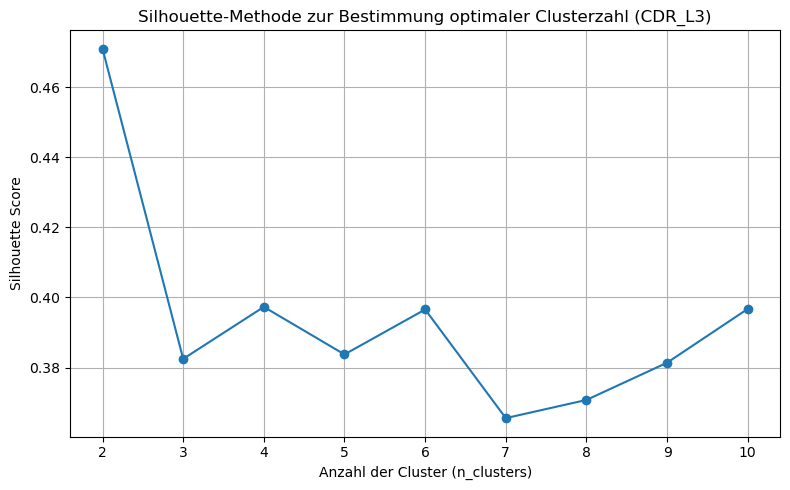

In [7]:
# Silhouette-Methode zur Bestimmung der optimalen Clusterzahl

for region in regions:
    feature_space_silhouette = feature_spaces[region]
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns = ["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)

    # Cluster-Range
    cluster_range = range(2, 11)
    silhouette_values = []

    # Berechne Silhouette Score für jede Clusteranzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(coords)
        score = silhouette_score(coords, labels)
        silhouette_values.append(score)

    # Plot Silhouette-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, silhouette_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.grid(True)
    plt.xticks(cluster_range)
    plt.tight_layout()
    plt.show()


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


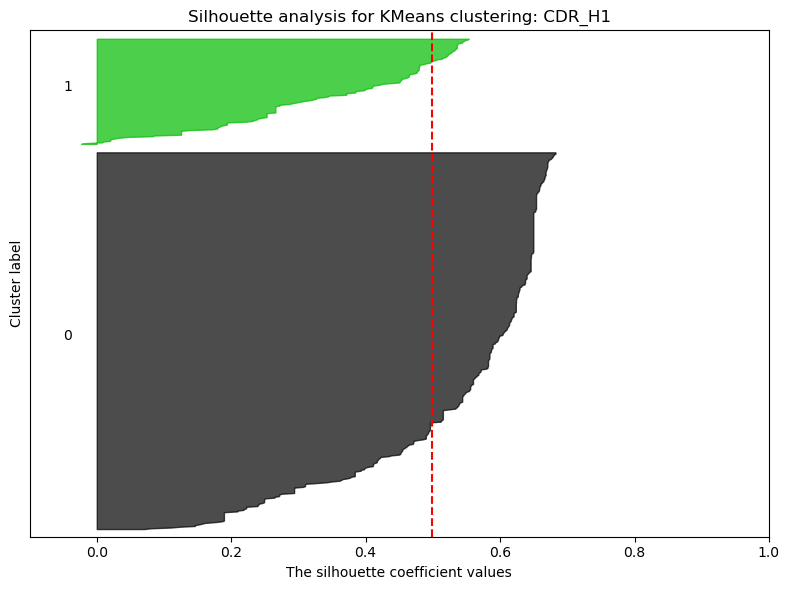

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


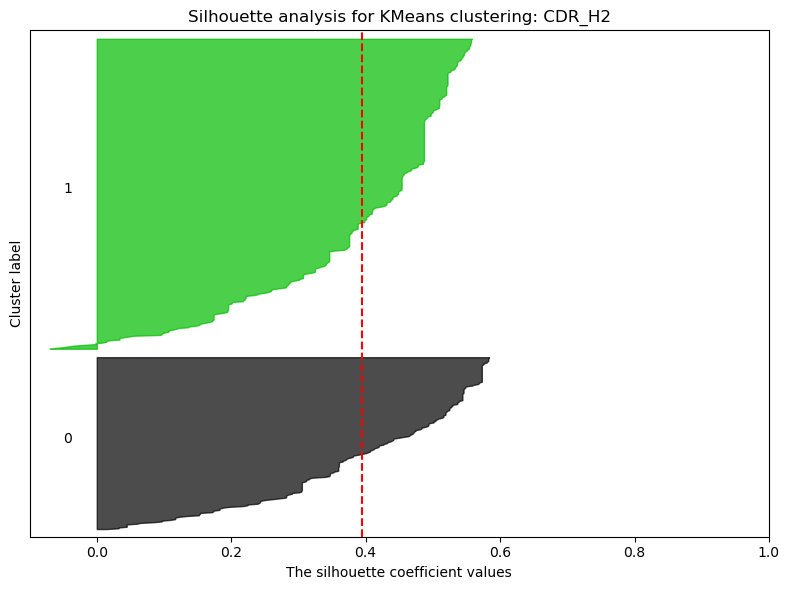

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


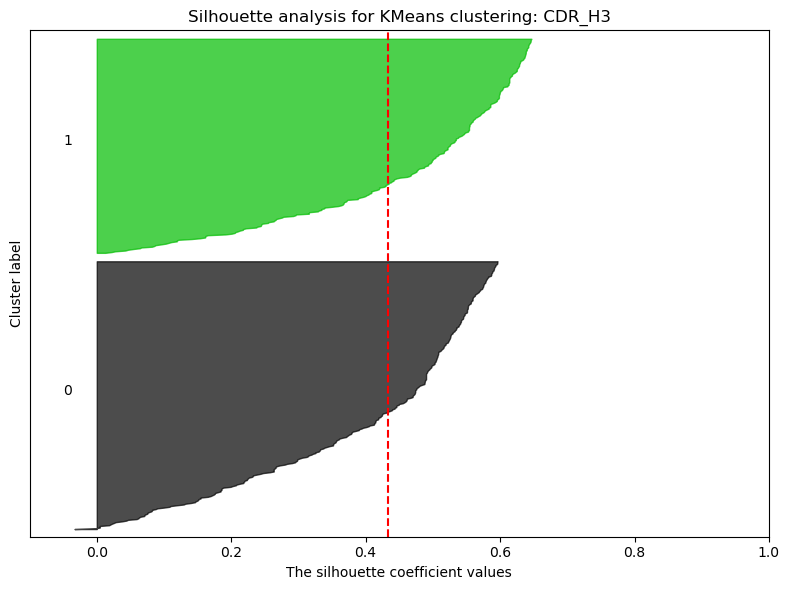

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


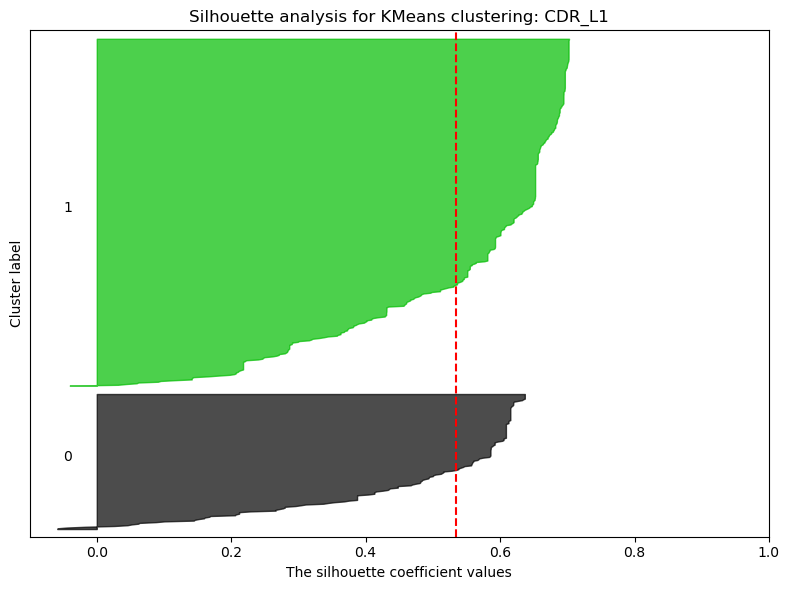

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


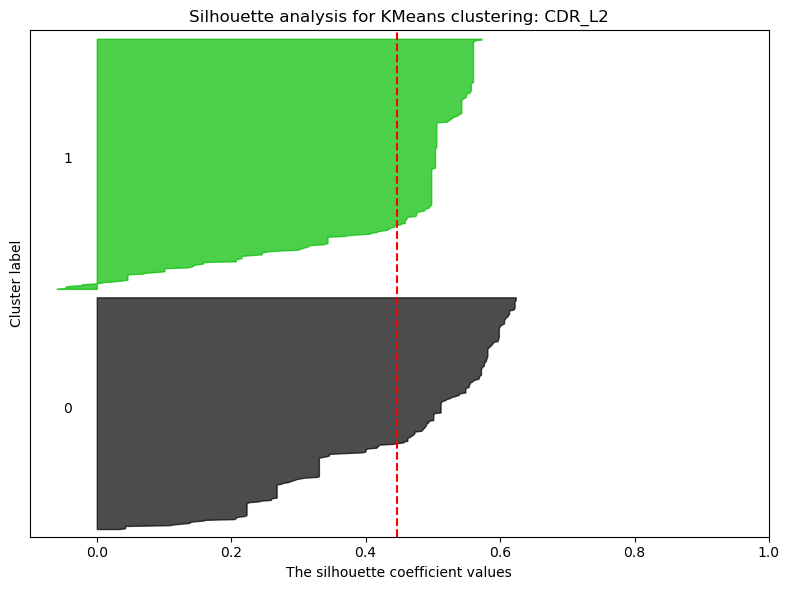

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


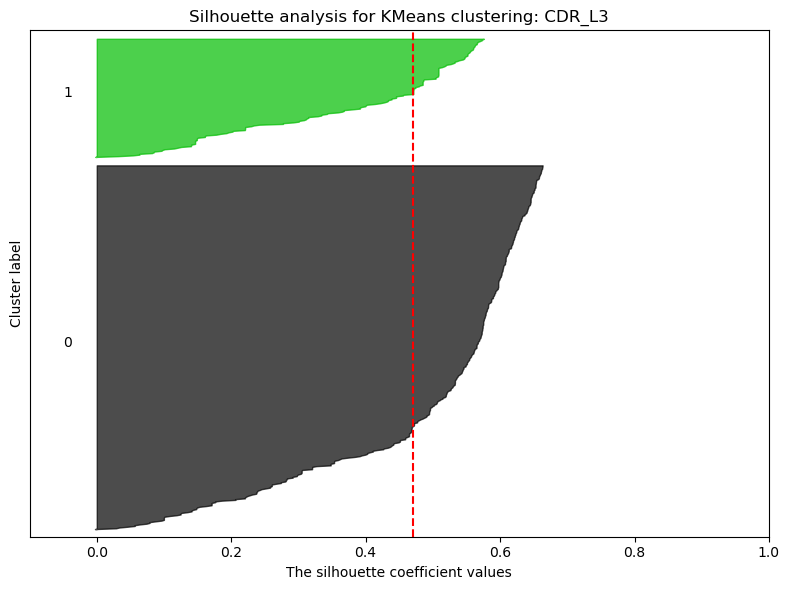

In [8]:
# Silhouette-Methode zur Bestimmung der optimalen Clusterzahl
for region in regions:
    feature_space_silhouette = feature_spaces[region]
    X = feature_space_silhouette.drop(columns=["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)
    
    # Nutze 2D-PCA-Koordinaten für Visualisierung + Silhouette
    coords = PCA(n_components=2).fit_transform(X)
    n_clusters = 2  # kann angepasst werden
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(coords)

    # Silhouette-Berechnung

    # Cluster-Range
 
    silhouette_avg = silhouette_score(coords, cluster_labels)
    sample_silhouette_values = silhouette_samples(coords, cluster_labels)

    # Plot
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(8, 6)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette analysis for KMeans clustering: {region}")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])
    ax1.set_xlim([-0.1, 1.0])
    ax1.set_ylim([0, len(coords) + (n_clusters + 1) * 10])
    plt.tight_layout()
    plt.show()

      pdb                 antigen_name  \
0    8veb                hemagglutinin   
1    8ved                hemagglutinin   
2    8vef                hemagglutinin   
3    8vpf           spike glycoprotein   
4    9dpc                neuraminidase   
..    ...                          ...   
625  7n4i             spike protein s1   
626  6ss2                      unknown   
627  7m42             spike protein s1   
628  7m42             spike protein s1   
629  4olv  envelope glycoprotein gp160   

                                     antigen_species  embedding_dimension 0  \
0                                  influenza a virus               0.011432   
1                                  influenza a virus               0.041635   
2                                  influenza a virus               0.003515   
3      severe acute respiratory syndrome coronavirus              -0.000650   
4                                  influenza a virus               0.014122   
..                   

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


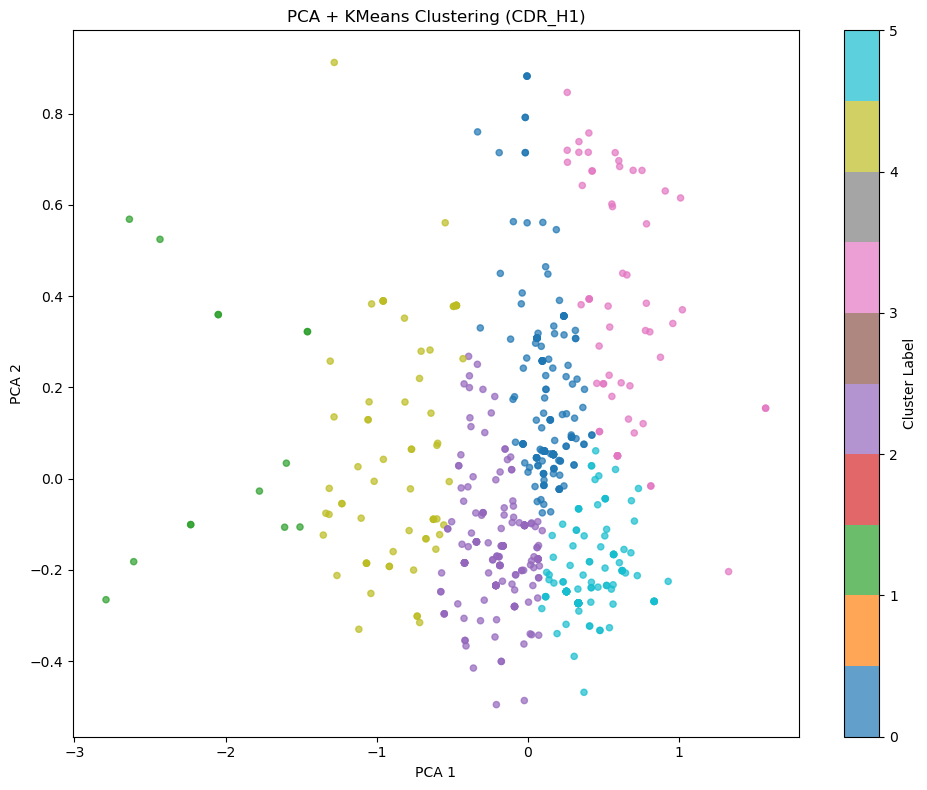


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike protein s1: 62x
  spike glycoprotein: 56x
  hemagglutinin: 14x
  envelope glycoprotein e2: 7x
  neuraminidase: 7x
  surface glycoprotein: 7x
  hemagglutinin | hemagglutinin: 3x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 3x
  envelope glycoprotein gp160: 3x
  unknown: 3x
  clade a/e 93th057 hiv-1 gp120 core: 2x
  envelope glycoprotein gp120: 2x
  fusion glycoprotein f0: 1x
  gametocyte surface protein p230: 1x
  programmed cell death protein 1: 1x

Cluster 1:
  spike glycoprotein: 4x
  envelope glycoprotein gp120: 2x
  clade a/e 93th057 hiv-1 gp120 core: 2x
  neuraminidase: 1x
  unknown: 1x
  spike protein s1: 1x
  envelope glycoprotein gp160: 1x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 1x
  hemagglutinin: 1x

Cluster 2:
  spike glycoprotein: 53x
  spike protein s1: 42x
  envelope glycoprotein gp160: 13x
  hemagglutinin: 9x
  clade a/e 93th057 hiv-1 gp120 core: 9x
  neuraminidase: 8x
  unknown: 6x
 

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


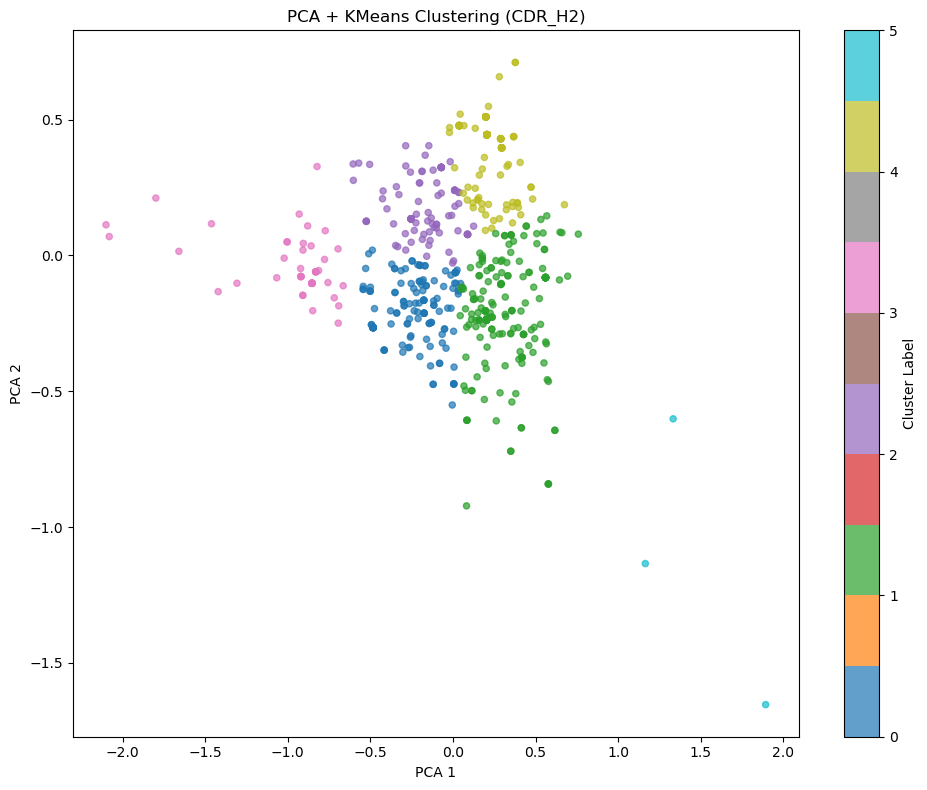


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike glycoprotein: 44x
  spike protein s1: 40x
  gametocyte surface protein p230: 9x
  neuraminidase: 8x
  clade a/e 93th057 hiv-1 gp120 core: 8x
  hemagglutinin: 7x
  envelope glycoprotein gp160: 7x
  hemagglutinin | hemagglutinin: 6x
  envelope glycoprotein e2: 5x
  envelope glycoprotein gp120: 5x
  programmed cell death protein 1: 3x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 3x
  unknown: 2x
  fusion glycoprotein f0: 1x
  surface glycoprotein: 1x

Cluster 1:
  spike glycoprotein: 65x
  spike protein s1: 55x
  hemagglutinin: 16x
  fusion glycoprotein f0: 10x
  neuraminidase: 9x
  surface glycoprotein: 7x
  hemagglutinin | hemagglutinin: 5x
  gametocyte surface protein p230: 5x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 4x
  envelope glycoprotein gp120: 4x
  envelope glycoprotein gp160: 4x
  envelope glycoprotein e2: 3x
  programmed cell death protein 1: 2x
  unknown: 1x

Cluster 2:
  spike protein s1: 

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


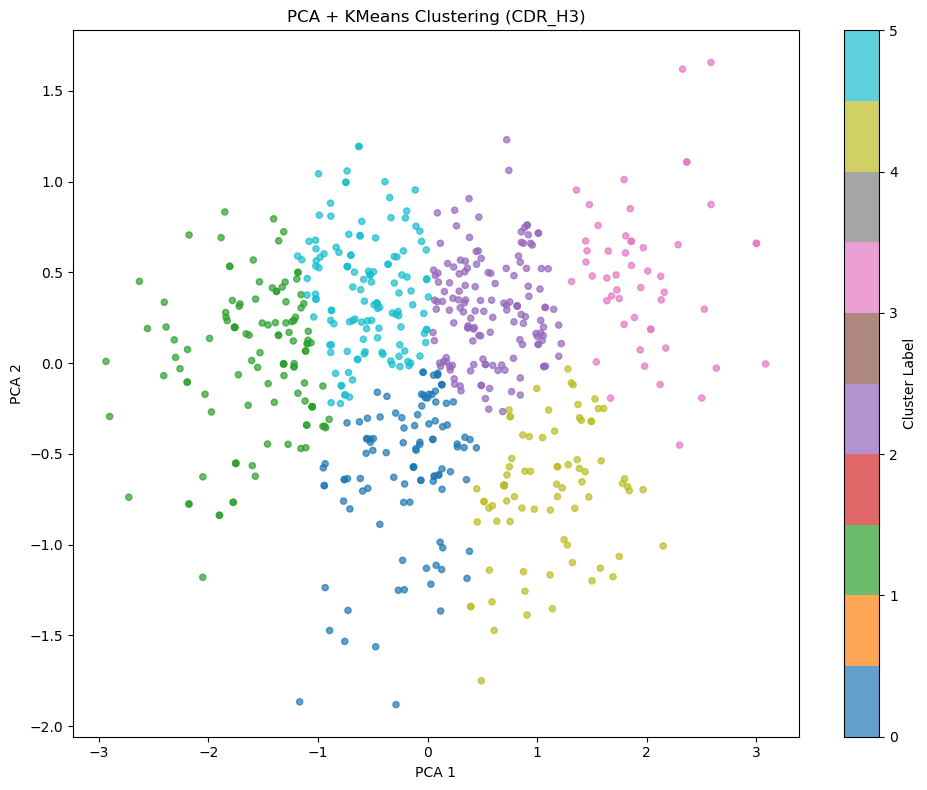


 Antigen Häufigkeiten pro Cluster für CDR_H3 

Cluster 0:
  spike protein s1: 44x
  spike glycoprotein: 29x
  hemagglutinin: 11x
  gametocyte surface protein p230: 6x
  envelope glycoprotein e2: 4x
  fusion glycoprotein f0: 3x
  surface glycoprotein: 3x
  unknown: 2x
  neuraminidase: 1x
  hemagglutinin | hemagglutinin: 1x
  envelope glycoprotein gp120: 1x
  clade a/e 93th057 hiv-1 gp120 core: 1x

Cluster 1:
  spike protein s1: 44x
  spike glycoprotein: 39x
  programmed cell death protein 1: 8x
  surface glycoprotein: 7x
  clade a/e 93th057 hiv-1 gp120 core: 3x
  hemagglutinin: 3x
  envelope glycoprotein e2: 2x
  unknown: 2x
  fusion glycoprotein f0: 2x
  gametocyte surface protein p230: 2x
  hemagglutinin | hemagglutinin: 1x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 1x
  neuraminidase: 1x
  envelope glycoprotein gp120: 1x

Cluster 2:
  spike glycoprotein: 40x
  spike protein s1: 25x
  hemagglutinin: 16x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 10x
  fusion glyco

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


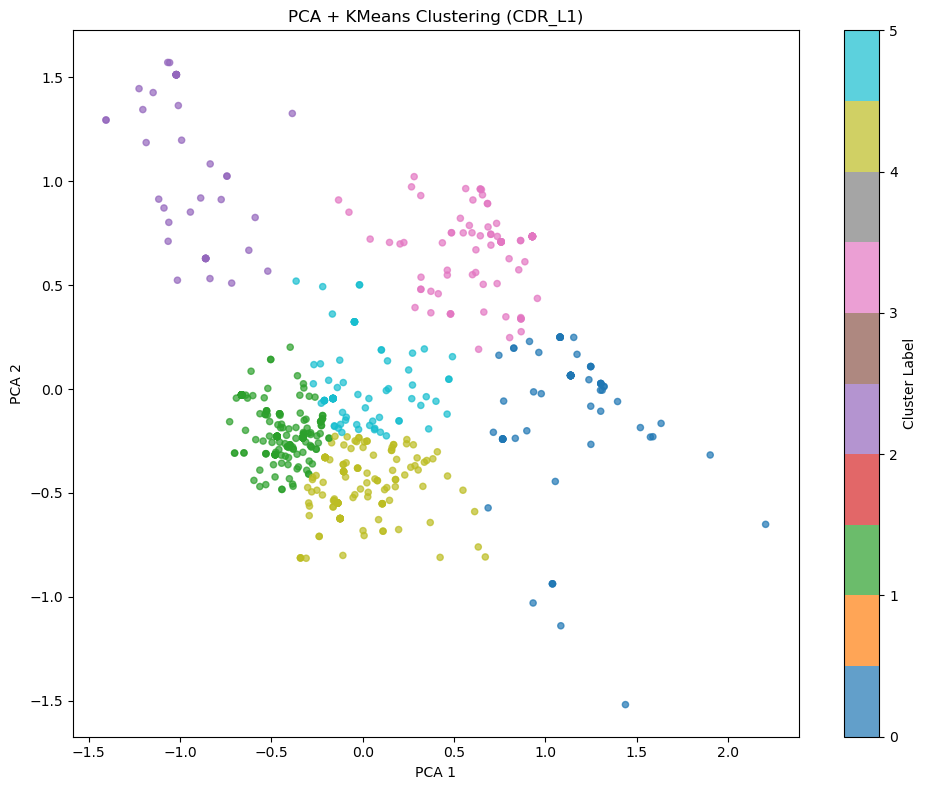


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  spike protein s1: 25x
  spike glycoprotein: 23x
  unknown: 6x
  hemagglutinin: 4x
  hemagglutinin | hemagglutinin: 4x
  neuraminidase: 3x
  fusion glycoprotein f0: 3x
  envelope glycoprotein e2: 2x
  envelope glycoprotein gp160: 1x
  envelope glycoprotein gp120: 1x
  surface glycoprotein: 1x
  clade a/e 93th057 hiv-1 gp120 core: 1x

Cluster 1:
  spike protein s1: 77x
  spike glycoprotein: 62x
  hemagglutinin: 12x
  surface glycoprotein: 12x
  neuraminidase: 11x
  envelope glycoprotein e2: 10x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 6x
  hemagglutinin | hemagglutinin: 5x
  programmed cell death protein 1: 5x
  gametocyte surface protein p230: 5x
  fusion glycoprotein f0: 4x
  clade a/e 93th057 hiv-1 gp120 core: 2x
  envelope glycoprotein gp120: 2x
  unknown: 2x
  envelope glycoprotein gp160: 1x

Cluster 2:
  spike protein s1: 12x
  spike glycoprotein: 12x
  hemagglutinin: 6x
  surface glycoprotein: 3x
  gametocyte

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


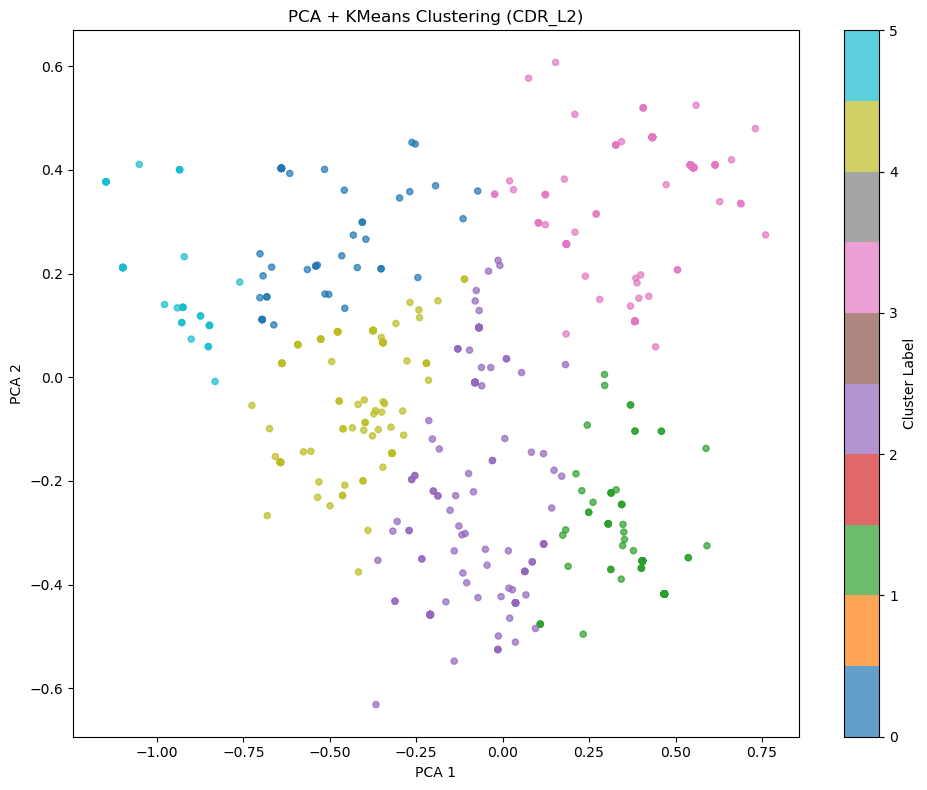


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike protein s1: 18x
  spike glycoprotein: 13x
  hemagglutinin: 10x
  hemagglutinin | hemagglutinin: 4x
  envelope glycoprotein gp120: 2x
  envelope glycoprotein gp160: 2x
  neuraminidase: 1x
  unknown: 1x

Cluster 1:
  spike protein s1: 52x
  spike glycoprotein: 36x
  hemagglutinin: 7x
  neuraminidase: 6x
  programmed cell death protein 1: 6x
  surface glycoprotein: 5x
  hemagglutinin | hemagglutinin: 3x
  envelope glycoprotein e2: 3x
  gametocyte surface protein p230: 2x
  clade a/e 93th057 hiv-1 gp120 core: 2x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 2x
  unknown: 1x
  fusion glycoprotein f0: 1x

Cluster 2:
  spike glycoprotein: 53x
  spike protein s1: 39x
  hemagglutinin: 10x
  fusion glycoprotein f0: 8x
  gametocyte surface protein p230: 8x
  neuraminidase: 5x
  programmed cell death protein 1: 5x
  surface glycoprotein: 4x
  envelope glycoprotein e2: 3x
  envelope glycoprotein gp160: 3x
  envelope glycoprot

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


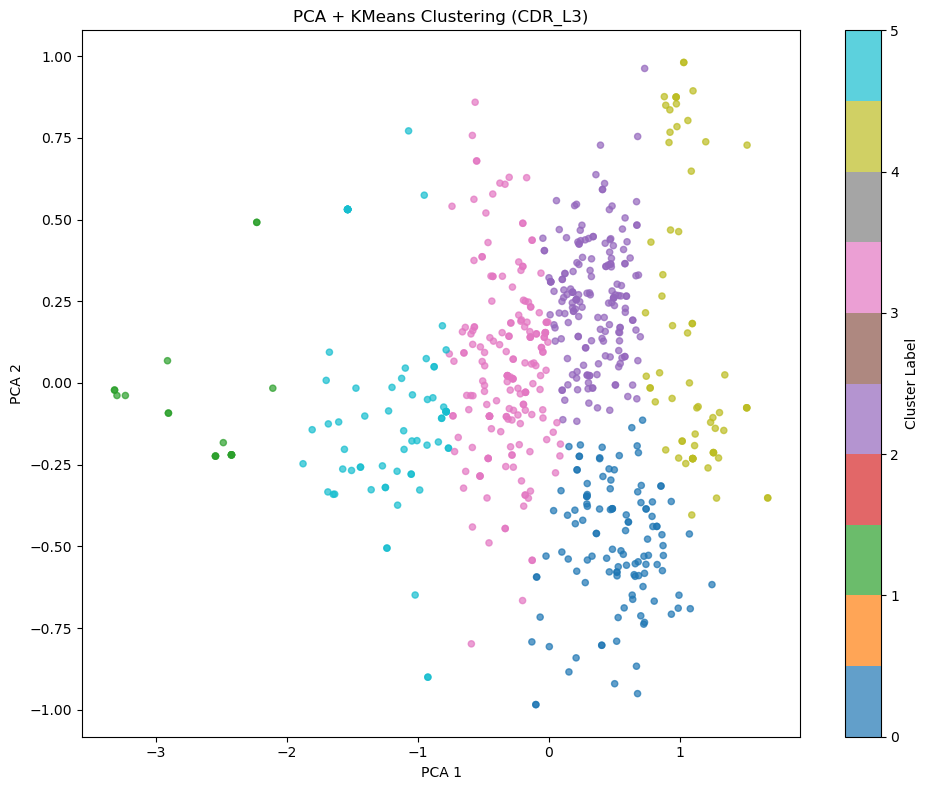


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  spike protein s1: 39x
  spike glycoprotein: 33x
  hemagglutinin: 16x
  fusion glycoprotein f0: 6x
  unknown: 5x
  neuraminidase: 5x
  surface glycoprotein: 3x
  clade a/e 93th057 hiv-1 gp120 core: 3x
  hemagglutinin | hemagglutinin: 3x
  programmed cell death protein 1: 2x
  envelope glycoprotein gp160: 2x
  envelope glycoprotein gp120: 1x

Cluster 1:
  spike glycoprotein: 7x
  spike protein s1: 5x
  programmed cell death protein 1: 2x
  hemagglutinin | hemagglutinin: 1x
  hemagglutinin: 1x
  envelope glycoprotein gp120: 1x
  surface glycoprotein: 1x
  clade a/e 93th057 hiv-1 gp120 core: 1x

Cluster 2:
  spike protein s1: 55x
  spike glycoprotein: 55x
  hemagglutinin: 12x
  surface glycoprotein: 11x
  neuraminidase: 10x
  gametocyte surface protein p230: 7x
  envelope glycoprotein e2: 6x
  hemagglutinin | hemagglutinin: 4x
  unknown: 4x
  programmed cell death protein 1: 4x
  fusion glycoprotein f0: 2x
  envelope glycoprotein

In [9]:
# Clustering auf basis der PCA
#kmeans mit 2 => laut elbow method am sinnvollsten

antigen_labels = df["antigen_name"].tolist()
for region in regions:
    feature_space_kmeans = feature_spaces[region]

    X = feature_space_kmeans.drop(columns=["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)
    print(feature_space_kmeans)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=6, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()
        

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")

In [10]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für CDR_H1
Cluster                                             0  1   2   3   4   5
Antigen                                                                 
clade a/e 93th057 hiv-1 gp120 core                  3  1   1  10   0   3
envelope glycoprotein e2                            0  0   6   7   1   1
envelope glycoprotein gp120                         1  1   0   7   4   0
envelope glycoprotein gp160                         2  0   2   4   2   9
fusion glycoprotein f0                              6  0   2   3   2   3
gametocyte surface protein p230                     0  0   7   5   0   3
hemagglutinin                                      16  1  12  13   5   6
hemagglutinin ha2 chain | hemagglutinin ha1 chain   0  0   2   8   1   1
hemagglutinin | hemagglutinin                       3  1   4   5   1   0
neuraminidase                                       5  0  10   3   2   5
programmed cell death protein 1                     2  2   4   4   0   2
spike glycoprotein  

In [11]:
# Brauchen wir erst mal nicht!
'''# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling
from scipy.spatial.distance import directed_hausdorff
from sklearn.manifold import MDS

subset_df = df.sample(300, random_state=42)


for region in regions:
    alle_embeddings = []
    labels = []
    for i, df_row in subset_df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        #antigen_species = df_row["antigen_species"]
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        alle_embeddings.append(embedding_as_arr)
        labels.append(antigen_name)
    n = len(alle_embeddings)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist_matrix)

    label_codes = pd.Categorical(labels).codes
    label_categories = pd.Categorical(labels).categories
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=label_codes, cmap='tab10', s=20)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")
    plt.title(f"Embeddings der {region} (Hausdorff)")
    plt.grid(True)
    plt.show()'''

'# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling\nfrom scipy.spatial.distance import directed_hausdorff\nfrom sklearn.manifold import MDS\n\nsubset_df = df.sample(300, random_state=42)\n\n\nfor region in regions:\n    alle_embeddings = []\n    labels = []\n    for i, df_row in subset_df.iterrows():\n        pdb = df_row["pdb"]\n        antigen_name = df_row["antigen_name"]\n        #antigen_species = df_row["antigen_species"]\n        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")\n        alle_embeddings.append(embedding_as_arr)\n        labels.append(antigen_name)\n    n = len(alle_embeddings)\n    dist_matrix = np.zeros((n, n))\n    for i in range(n):\n        for j in range(i + 1, n):\n            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]\n            dist_matrix[i, j] = dist\n            dist_matrix[j, i] = dist\n    mds = MDS(n_components=2, dissimilarity=\'precomputed\', random_stat